# 01 · HC3 exploratory data analysis

In [1]:
import matplotlib.pyplot as plt

In [2]:
from logos.data.hc3 import load_hc3

hc3 = load_hc3()
print(hc3.shape)
print(hc3.nunique())
print(hc3.text.duplicated().sum())

(85431, 5)
text         79331
label            2
generator        2
family           2
domain           5
dtype: int64
6100


In [3]:
# The hc3 df is showing 6100 duplicate rows, all of which seem to be API error responses
hc3["text"].value_counts().head(10)

text
!\nToo many requests in 1 hour. Try again later.\n\n\n\nThere was an error generating a response                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            27
!Your authentication token has expired. Please try s

In [4]:
from logos.data.hc3 import clean_hc3

cleaned = clean_hc3(hc3)

errors = hc3[~hc3["text"].isin(cleaned["text"])]
print("error rows removed by regex:", len(errors), errors["label"].value_counts().rename({0: "human", 1: "chatgpt"}).to_dict())

non_error = hc3[hc3["text"].isin(cleaned["text"])]
dupes = non_error[non_error["text"].duplicated()]
print("duplicate rows removed by dedup:", len(dupes), dupes["label"].value_counts().rename({0: "human", 1: "chatgpt"}).to_dict())

errors[errors["label"] == 0]["text"].tolist()

loose = r"Too many requests|authentication token|network error|There was an error|ChatGPT Dec \d+ Version|Clear conversations"
tight = r"Too many requests in 1 hour|authentication token has expired|network error|There was an error generating a response|ChatGPT Dec \d+ Version|Clear conversations"
m = hc3["text"].str.contains(loose, case=False) & ~hc3["text"].str.contains(tight, case=False)
hc3[m][["label", "text"]]

error rows removed by regex: 171 {'chatgpt': 171}
duplicate rows removed by dedup: 5990 {'human': 5460, 'chatgpt': 530}


,label,text
4414,0,"The French has Le , La , and Les . The Spanish..."
24286,0,""" Stack overflow "" is a programming term relat..."
75825,1,To fetch technical indicators from Yahoo's API...


# Class imbalance

In [5]:
# Get the class counts
hc3["label"].value_counts().rename({0: "human", 1: "chatgpt"})

label
human      58546
chatgpt    26885
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,58546.0,133.857394,163.849899,1.0,42.0,83.0,162.0,7904.0
1,26885.0,173.186015,61.427422,1.0,131.0,174.0,212.0,639.0


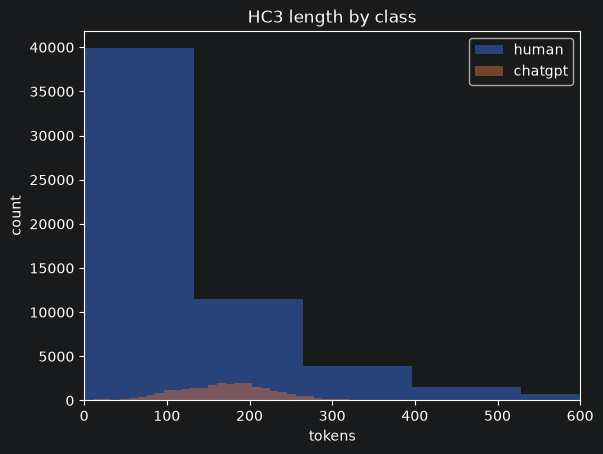

In [6]:
hc3["n_tokens"] = hc3["text"].str.split().map(len)
display(hc3.groupby("label")["n_tokens"].describe())

for label, group in hc3.groupby("label"):
    plt.hist(group["n_tokens"], bins=60, alpha=.5, label="human" if label == 0 else "chatgpt")

plt.xlim(0, 600)
plt.xlabel("tokens")
plt.ylabel("count")
plt.legend()
plt.title("HC3 length by class")
plt.show()

In [7]:
# Domain balance is heavily skewed towards reddit_eli5
hc3.groupby(["domain", "label"]).size().unstack(fill_value=0)

label,0,1
domain,,
finance,3933,4503
medicine,1248,1334
open_qa,1187,3546
reddit_eli5,51336,16660
wiki_csai,842,842


In [8]:
"""
In order to filter out text that is too short,
find out how many rows will be dropped by minimum token amount.
As we can observe, 10 would catch too few, and 25 would catch too many
short answers. 15 would remove majority of genuine texts of one line or less
"""
for minimum_tokens in (10, 15, 25):
  drop = hc3[hc3.n_tokens < minimum_tokens]["label"].value_counts().rename({0:"human",1:"chatgpt"})
  print(minimum_tokens, drop.to_dict())

10 {'human': 576, 'chatgpt': 63}
15 {'human': 2451, 'chatgpt': 95}
25 {'human': 6885, 'chatgpt': 220}


In [9]:
from logos.data.hc3 import load_hc3, clean_hc3
from logos.data.preprocess import preprocess, train_val_split

hc3 = preprocess(clean_hc3(load_hc3()), min_tokens=15)
train_df, val_df = train_val_split(hc3, val_fraction=0.15)

print("clean corpus:", hc3.shape, "| min tokens:", hc3.text.str.split().map(len).min())
print("train:", train_df.shape, "| val (tau* calibration):", val_df.shape)
print("val human/chatgpt:", val_df.label.value_counts().rename({0:"human",1:"chatgpt"}).to_dict())

clean corpus: (77066, 5) | min tokens: 15
train: (65506, 5) | val (tau* calibration): (11560, 5)
val human/chatgpt: {'human': 7639, 'chatgpt': 3921}


## Observations and cleaning decisions

### Duplicates

Raw load = 85,431 rows - 79,331 unique texts = 6,100 duplicate rows.

- The most frequent repeats in `value_counts()` are ChatGPT API-error responses and UI dumps.
- An HC3 denylist regex (`clean_hc3`) matches the full error messages and removes 171 rows of chatgpt messages. This would increase the classifier's chatgpt bias if left in.
- The regex captures only a small share of the duplicates: 5,460 human and 530 chatgpt answers, mostly repeated reddit_eli5 answers, and removes them using exact-text deduplication.

**Cleaned corpus: 79,270 rows, all unique.**

### Length / fragments

- After cleaning, token counts still reach a single token.
- ChatGPT is very verbose, with a mean of 174 and a standard deviation of 61. Human text is much more common and has a much higher mean and standard deviation, with a maximum of 7,904.
- After removing 2,157 human and 47 chatgpt fragments (~2.8% of the corpus), the remaining answers are still useful: human answers are 42 and chatgpt answers are 132.

*Note:* The detector can separate partly by verbosity, but it does not correct the length difference. This is recorded as motivation for the lexical-baseline floor and the RQ3 reliability analysis, not something to correct by truncation.

### Class balance

- After cleaning, about 2:1 human:chatgpt (53,086 human, 26,184 chatgpt) remained, and the token filter removed 2,157 short human answers.
- The imbalance is driven by reddit_eli5 (45,965 of the 53,086 human answers), mainly because of open_qa.

#### Not rebalanced

TPR@1%FPR is not affected by class proportions, so imbalance does not affect the metric. In classifier training, use `class_weight="balanced"` to keep all data, not discard ~27k rows.

### Domain skew

- reddit_eli5 dominates (62,036 of 79,270 rows) and is human-heavy; open_qa is chatgpt-heavy (1,171 / 3,516); finance (3,933 / 4,457), medicine (1,246 / 1,299) and wiki_csai (771 / 841) are near-balanced.
- HC3 is therefore effectively a reddit corpus. Use HC3 as a reference when interpreting any HC3-derived in-distribution result, because the domain and generator shift are measured on MAGE.

### Rules for `preprocess`:
- min_tokens = 15
- dedupe = yes (exact text)
- balance classes = no (prevalence-invariant metric; `class_weight="balanced"` at train time).
- In `clean_hc3`, remove HC3 errors and exact-text duplicates, then apply the token filter. The corpus is split 85/15 by label, with 65,506 train and 11,560 validation. The validation set is 7,639 humans, and they use the frozen threshold τ*.